In [1]:
import pandas as pd

from cellosaurus_utils import *

brca_df, seqvar_df = get_cell_line_cellosaurus_annotations(file_dir=features_dir)
seqvar_df_filtered = filter_sequence_variation_modality(seqvar_df)

File 'cellosaurus.txt' already exists in /Users/frohlif/Documents/projects/DeepMechanisticModels/features. Skipping download.


In [2]:
brca_df["Primary/Metastatic"] = brca_df["Site"].str.split(";").str[0]
brca_df["Primary/Metastatic"]

cell_line
c184A1         In situ
c184B5         In situ
cAU565      Metastatic
cBT20          In situ
cBT474         In situ
               ...    
cUACC812       In situ
cUACC893       In situ
cZR751      Metastatic
cZR7530     Metastatic
cZR75B      Metastatic
Name: Primary/Metastatic, Length: 63, dtype: object

In [3]:
brca_df["Disease"]

cell_line
c184A1                                           Unknown
c184B5                                           Unknown
cAU565                             Breast adenocarcinoma
cBT20       Invasive breast carcinoma of no special type
cBT474      Invasive breast carcinoma of no special type
                                ...                     
cUACC812    Invasive breast carcinoma of no special type
cUACC893    Invasive breast carcinoma of no special type
cZR751      Invasive breast carcinoma of no special type
cZR7530     Invasive breast carcinoma of no special type
cZR75B      Invasive breast carcinoma of no special type
Name: Disease, Length: 63, dtype: object

HCC2185 is the only `Metastatic breast lobular carcinoma` in the dataset

In [4]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs_tegfr_aggavg", data="dream_cytof"))
del petab_base_files["condition_table"]

transcriptomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
tegfr = transcriptomics["EGFR"]
tegfr -= tegfr.mean()
terbb2 = transcriptomics["ERBB2"]
terbb2 -= terbb2.mean()
del transcriptomics

proteomics, _, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pegfr = proteomics["EGFR"]
pegfr -= pegfr.mean()
perbb2 = proteomics["ERBB2"]
perbb2 -= perbb2.mean()
del proteomics

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/bionetgen/main.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


# Check subtype influence/trend/overlay on EGFR / ERBB2 levels (protein vs transcript)

<Axes: xlabel='tEGFR', ylabel='pEGFR'>

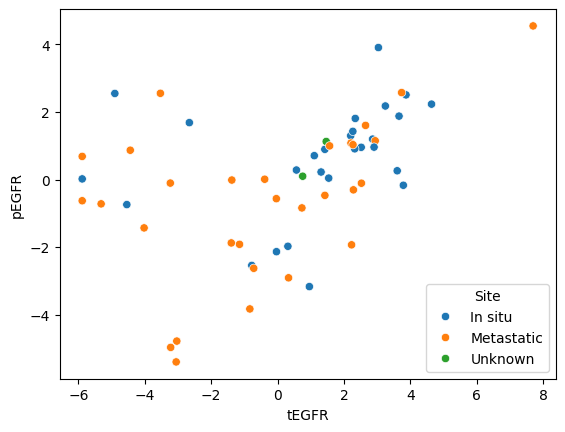

In [5]:
egfr_levels = tegfr.rename("tEGFR").copy()
egfr_levels = egfr_levels.reset_index().set_index("preequilibrationConditionId")
egfr_levels["pEGFR"] = pegfr.rename("pEGFR").reindex(egfr_levels.index)
egfr_levels.index.name = "cell_line"
egfr_levels["Site"] = brca_df["Primary/Metastatic"].reindex(egfr_levels.index)

import seaborn as sns

sns.scatterplot(
    egfr_levels,
    x="tEGFR",
    y="pEGFR",
    hue="Site"
)

<Axes: xlabel='tERBB2', ylabel='pERBB2'>

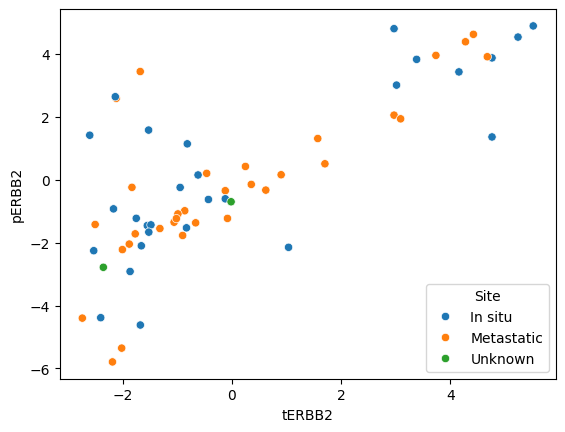

In [6]:
erbb2_levels = terbb2.rename("tERBB2").copy()
erbb2_levels = erbb2_levels.reset_index().set_index("preequilibrationConditionId")
erbb2_levels["pERBB2"] = perbb2.rename("pERBB2").reindex(egfr_levels.index)
erbb2_levels.index.name = "cell_line"
erbb2_levels["Site"] = brca_df["Primary/Metastatic"].reindex(egfr_levels.index)

import seaborn as sns

sns.scatterplot(
    erbb2_levels,
    x="tERBB2",
    y="pERBB2",
    hue="Site"
)

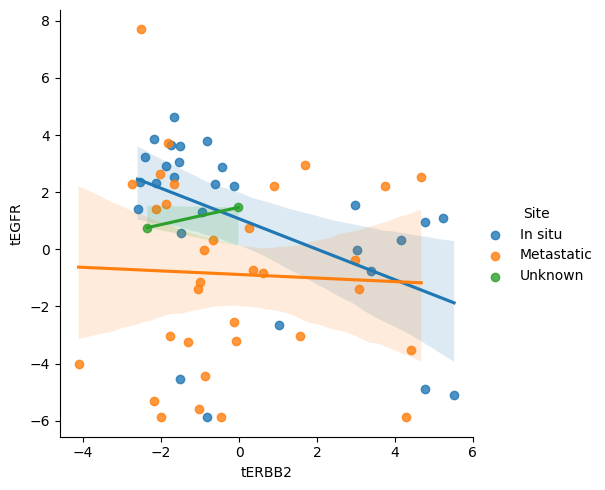

In [7]:
all_levels = pd.merge(
    erbb2_levels,
    egfr_levels,
    left_index=True,
    right_index=True
)
all_levels.drop(columns=["Site_y"], inplace=True)
all_levels.rename(columns={"Site_x": "Site"}, inplace=True)

sns.lmplot(
    all_levels,
    x="tERBB2",
    y="tEGFR",
    hue="Site"
)

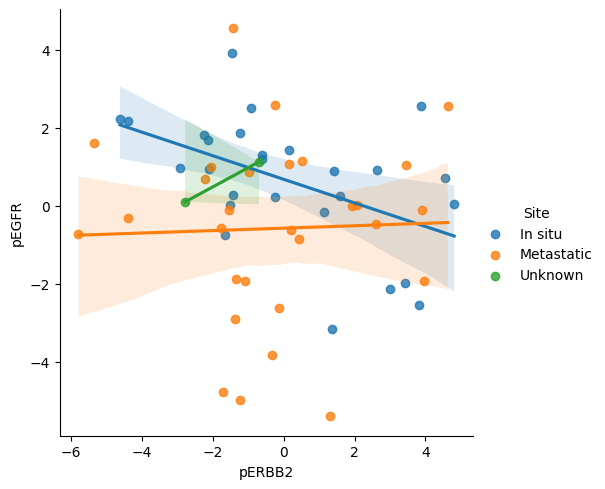

In [8]:
sns.lmplot(
    all_levels,
    x="pERBB2",
    y="pEGFR",
    hue="Site"
)

# Any structure re. primary tumour/metastasis in the phospho-proteomics data (either full or time 0)? No

<Axes: xlabel='PCA1', ylabel='PCA2'>

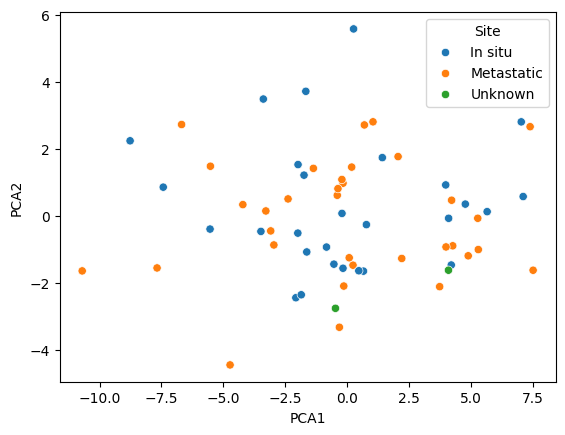

In [9]:
cytof_dynamic, _, _, _ = load_data(
    contextualization="cytof_dynamic",
    samples=samples,
    features=None,
    **petab_base_files,
)

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

knn = KNNImputer()
knn.fit(cytof_dynamic)
pca = PCA(n_components=2)

pca_cytof_dynamic = pd.DataFrame(
    pca.fit_transform(knn.transform(cytof_dynamic)),
    index=cytof_dynamic.index,
    columns=["PCA1", "PCA2"]
)

pca_cytof_dynamic["Site"] = brca_df["Primary/Metastatic"].loc[pca_cytof_dynamic.index]

sns.scatterplot(
    pca_cytof_dynamic,
    x="PCA1",
    y="PCA2",
    hue="Site"
)

<Axes: xlabel='PCA1', ylabel='PCA2'>

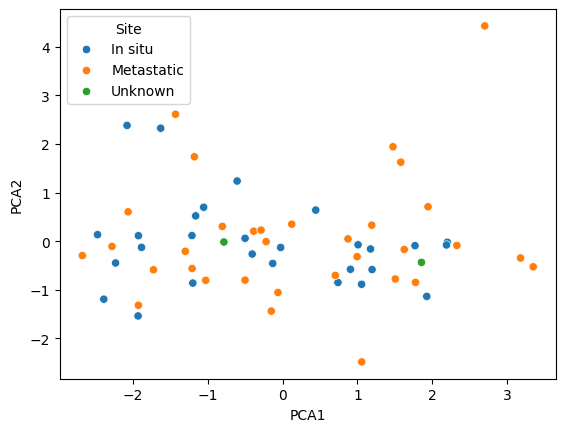

In [10]:
cytof_init, _, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples,
    features=None,
    **petab_base_files,
)

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

knn = KNNImputer()
knn.fit(cytof_init)
pca = PCA(n_components=2)

pca_cytof_init = pd.DataFrame(
    pca.fit_transform(knn.transform(cytof_init)),
    index=cytof_dynamic.index,
    columns=["PCA1", "PCA2"]
)

pca_cytof_init["Site"] = brca_df["Primary/Metastatic"].loc[pca_cytof_dynamic.index]

sns.scatterplot(
    pca_cytof_init,
    x="PCA1",
    y="PCA2",
    hue="Site"
)

# Check frequent mutations

In [11]:
# Threshold: 10% of total rows
threshold = 0.1 * len(seqvar_df)

# Count non-zero values per column
non_zero_counts = (seqvar_df > 0).sum(axis=0)

# Filter columns above threshold
frequent_columns = non_zero_counts[non_zero_counts > threshold].index.tolist()

frequent_columns

['CDH1_M', 'TP53_M', 'PIK3CA_M', 'PTEN_M']

In [12]:
non_zero_counts

CDH1_M         8
KRAS_M         4
MAP2K4_M       3
TP53_M        42
CDKN2A_D       6
PIK3CA_M      17
RB1_M          5
AHCTF1_F       1
DOK5_F         1
IKZF3_F        1
MRPL45_F       1
MYO9B_F        1
BRCA2_M        4
HNF1A_M        1
MAPK1_M        1
CLTC_F         2
PTEN_M         9
RRAS2_M        1
MAP2K4_D       1
RB1_D          1
APC_M          1
BRAF_M         4
ABCG1_F        1
FHIT_M         3
PTEN_D         1
BRCA1_M        4
TMPRSS2_M      2
MET_M          1
GRK3_F         1
KDM6A_M        1
HRAS_M         3
MT-CYB_M       1
GATA3_M        2
CDKN2B_D       2
MSH6_M         1
NRG1_F         1
TERT_M         1
CDKN2A_M       1
FHIT_D         1
AR_M           1
CHD4_M         1
RET_M          1
CDH1_D         1
APPBP2_F       1
ARHGAP32_F     1
BCAS3_F        1
COL14A1_F      1
CWC25_F        1
DDX5_F         1
ENPP2_F        1
LASP1_F        1
NRIP1_F        1
OPRD1_F        1
PCGF2_F        1
dtype: int64

# Train simple random forest regressor from sequence variations to `cytof_dynamic` and evaluate feature importances across splits

In [13]:
seqvar_df_filtered[frequent_columns]

,CDH1_M,TP53_M,PIK3CA_M,PTEN_M
cell_line,,,,
c184A1,0.0,0.0,0.0,0.0
c184B5,0.0,0.0,0.0,0.0
cAU565,0.0,1.0,0.0,0.0
cBT20,0.0,1.0,0.5,0.0
cBT474,0.0,1.0,0.5,0.0
...,...,...,...,...
cUACC812,0.5,0.0,0.0,0.0
cUACC893,1.0,1.0,0.5,0.0
cZR751,0.0,0.0,0.0,1.0


In [15]:
from common import training_samples, val_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from dmm.initialisation import impute_features
from sklearn.ensemble import RandomForestRegressor
from util import load_petab_base_files

np.random.seed(42)

for split in ["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"]:
    conf = Conf(model="EGFR_MAPK__logobs_tegfr_aggavg", data="dream_cytof", samples=split)
    samples_train, samples_val = training_samples(conf), val_samples(conf)

    inputs_train = seqvar_df_filtered.loc[samples_train]
    inputs_val = seqvar_df_filtered.loc[samples_val]

    petab_base_files = load_petab_base_files(conf)
    del petab_base_files["condition_table"]

    targets_train, features_train, _, imputer = load_data(
        contextualization="cytof_dynamic",
        samples=samples_train,
        features=None,
        **petab_base_files,
    )

    targets_val, _, _, _ = load_data(
        contextualization="cytof_dynamic",
        samples=samples_val,
        features=features_train,
        imputer=imputer,
        **petab_base_files,
    )

    assert inputs_val.index.values == targets_val.index.values

    targets = impute_features({"train": targets_train, "val": targets_val})
    targets_train, targets_val = targets["train"], targets["val"]

    rf = RandomForestRegressor()
    rf.fit(inputs_train, targets_train.values)

    train_pred = rf.predict(inputs_train)
    val_pred = rf.predict(inputs_val)

    train_rmse = np.sqrt(np.mean((train_pred - targets_train.values) ** 2))
    val_rmse = np.sqrt(np.mean((val_pred - targets_val.values) ** 2))
    print(f"Split: {split}, Training RMSE: {train_rmse:.3f}, Validation RMSE: {val_rmse:.3f}")

    importances = sorted(
        zip(inputs_train.columns, rf.feature_importances_),
        key=lambda x: x[1],
        reverse=True
    )[:5]

    for name, importance in importances:
        print(f"{name}: {importance:.4f}")


Split: MCF7, Training RMSE: 0.395, Validation RMSE: 0.642
TP53_M: 0.1848
CDH1_M: 0.1650
PIK3CA_M: 0.1473
BRAF_M: 0.0782
BRCA2_M: 0.0770
Split: BT20, Training RMSE: 0.395, Validation RMSE: 0.885
TP53_M: 0.2092
PIK3CA_M: 0.1634
CDH1_M: 0.1446
BRAF_M: 0.0761
BRCA2_M: 0.0674
Split: HCC1500, Training RMSE: 0.378, Validation RMSE: 1.075
TP53_M: 0.2072
CDH1_M: 0.1560
PIK3CA_M: 0.1536
CDKN2A_D: 0.0783
BRAF_M: 0.0681
Split: EVSAT, Training RMSE: 0.400, Validation RMSE: 0.717
TP53_M: 0.2030
PIK3CA_M: 0.1662
CDH1_M: 0.1111
BRCA2_M: 0.0779
BRAF_M: 0.0768
Split: UACC3199, Training RMSE: 0.383, Validation RMSE: 0.892
TP53_M: 0.1995
PIK3CA_M: 0.1576
CDH1_M: 0.1405
BRCA2_M: 0.0780
CDKN2A_D: 0.0722


## EDA - CelloSaurus

In [16]:
brca_df.columns

Index(['ID', 'Site', 'MS_Status', 'Disease', 'Sequence_Variation', 'CDH1',
       'KRAS', 'MAP2K4', 'TP53', 'CDKN2A', 'PIK3CA', 'RB1', 'AHCTF1', 'DOK5',
       'IKZF3', 'MRPL45', 'MYO9B', 'BRCA2', 'HNF1A', 'MAPK1', 'CLTC', 'PTEN',
       'RRAS2', 'APC', 'BRAF', 'ABCG1', 'FHIT', 'BRCA1', 'TMPRSS2', 'MET',
       'GRK3', 'KDM6A', 'HRAS', 'MT-CYB', 'GATA3', 'CDKN2B', 'MSH6', 'NRG1',
       'TERT', 'AR', 'CHD4', 'RET', 'APPBP2', 'ARHGAP32', 'BCAS3', 'COL14A1',
       'CWC25', 'DDX5', 'ENPP2', 'LASP1', 'NRIP1', 'OPRD1', 'PCGF2',
       'Primary/Metastatic'],
      dtype='object')

In [17]:
brca_df["Site"].unique()

array(['In situ; Breast, epithelium', 'Metastatic; Pleural effusion',
       'In situ; Breast', 'Metastatic; Skin', 'Metastatic; Ascites',
       'Unknown', 'In situ; Peripheral blood', 'Metastatic; Brain',
       'Metastatic; Pericardial effusion',
       'Metastatic; Axillary lymph node'], dtype=object)

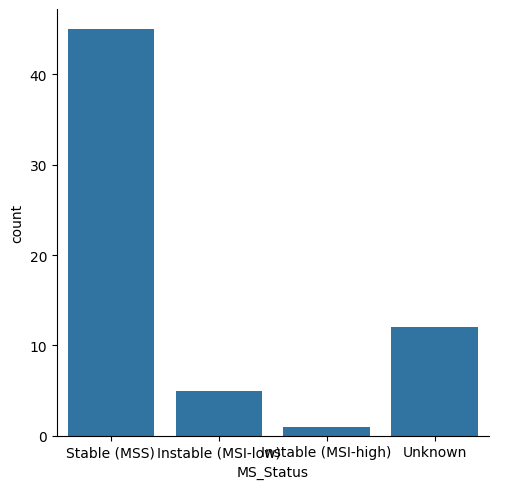

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(data=brca_df, x='MS_Status', kind='count', order=["Stable (MSS)", "Instable (MSI-low)", "Instable (MSI-high)", "Unknown"])

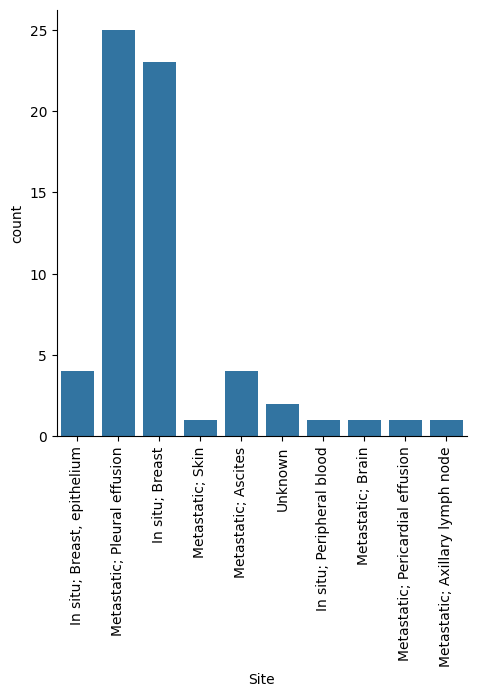

In [19]:
sns.catplot(data=brca_df, x='Site', kind='count')
plt.xticks(rotation=90);

Take a look at Instable cell-lines

In [20]:
brca_df[~brca_df["MS_Status"].isin(["Stable (MSS)", "Unknown"])]

,ID,Site,MS_Status,Disease,Sequence_Variation,CDH1,KRAS,MAP2K4,TP53,CDKN2A,...,BCAS3,COL14A1,CWC25,DDX5,ENPP2,LASP1,NRIP1,OPRD1,PCGF2,Primary/Metastatic
cell_line,,,,,,,,,,,,,,,,,,,,,
cCAL51,CVCL_1110,Metastatic; Pleural effusion,Instable (MSI-low),Breast carcinoma,"[{'type': 'Mutation', 'gene': 'PIK3CA', 'hgnc_...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metastatic
cHCC1500,CVCL_1254,In situ; Breast,Instable (MSI-low),Breast ductal carcinoma,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In situ
cHCC1569,CVCL_1255,In situ; Breast,Instable (MSI-high),Breast ductal carcinoma,"[{'type': 'Mutation', 'gene': 'BRCA2', 'hgnc_i...",NaN,NaN,NaN,"M (p.Glu294Ter), Heterozygous",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In situ
cMDAMB436,CVCL_0623,Metastatic; Pleural effusion,Instable (MSI-low),Invasive breast carcinoma of no special type,"[{'type': 'Gene deletion', 'gene': 'FHIT', 'hg...",NaN,NaN,NaN,"M (p.Glu204fs), Unspecified",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metastatic
cOCUBM,CVCL_1621,Metastatic; Pleural effusion,Instable (MSI-low),Breast carcinoma,"[{'type': 'Mutation', 'gene': 'CHD4', 'hgnc_id...",NaN,NaN,NaN,"M (p.Gly244Ser), Homozygous",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metastatic
cZR7530,CVCL_1661,Metastatic; Ascites,Instable (MSI-low),Invasive breast carcinoma of no special type,"[{'type': 'Gene fusion', 'gene': 'APPBP2', 'hg...","M (p.Glu243Ter), Homozygous",NaN,NaN,NaN,NaN,...,F,F,F,F,F,F,F,F,F,Metastatic


Take a look at cell-lines for which we lack any kind of info/annotation

In [21]:
brca_df[(brca_df["MS_Status"] == "Unknown") | (brca_df["Site"] == "Unknown")]

,ID,Site,MS_Status,Disease,Sequence_Variation,CDH1,KRAS,MAP2K4,TP53,CDKN2A,...,BCAS3,COL14A1,CWC25,DDX5,ENPP2,LASP1,NRIP1,OPRD1,PCGF2,Primary/Metastatic
cell_line,,,,,,,,,,,,,,,,,,,,,
c184B5,CVCL_4688,"In situ; Breast, epithelium",Unknown,Unknown,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In situ
cHBL100,CVCL_4362,Unknown,Stable (MSS),Unknown,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
cHCC2185,CVCL_3375,Metastatic; Pleural effusion,Unknown,Metastatic breast lobular carcinoma,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metastatic
cHCC3153,CVCL_3377,Unknown,Unknown,Breast ductal carcinoma,"[{'type': 'Gene fusion', 'gene': 'GRK3', 'hgnc...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
cLY2,CVCL_ZU84,In situ; Peripheral blood,Unknown,Nasopharyngeal carcinoma,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In situ
cMACLS2,CVCL_4571,Metastatic; Pleural effusion,Unknown,Breast ductal carcinoma,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metastatic
cMCF12A,CVCL_3744,"In situ; Breast, epithelium",Unknown,Unknown,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In situ
cMDAMB134VI,CVCL_0617,Metastatic; Pleural effusion,Unknown,Invasive breast lobular carcinoma,"[{'type': 'Mutation', 'gene': 'CDH1', 'hgnc_id...","M (p.Leu230fs), Homozygous","M (p.Gly12Arg), Heterozygous","M (p.Ser184Leu), Homozygous","M (p.Glu285Lys), Unspecified",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metastatic
cMPE600,CVCL_9875,Metastatic; Pleural effusion,Unknown,Invasive breast carcinoma of no special type,"[{'type': 'Mutation', 'gene': 'CDH1', 'hgnc_id...","M, Homozygous","M (p.Gly12Val), Heterozygous","M, Homozygous",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metastatic


In [22]:
brca_df["MS_Status"].value_counts()

MS_Status
Stable (MSS)           45
Unknown                12
Instable (MSI-low)      5
Instable (MSI-high)     1
Name: count, dtype: int64

In [23]:
brca_df["Site"].value_counts()

Site
Metastatic; Pleural effusion        25
In situ; Breast                     23
In situ; Breast, epithelium          4
Metastatic; Ascites                  4
Unknown                              2
Metastatic; Skin                     1
In situ; Peripheral blood            1
Metastatic; Brain                    1
Metastatic; Pericardial effusion     1
Metastatic; Axillary lymph node      1
Name: count, dtype: int64

# Check `cbioportal` annotations

In [25]:
from cbio_py import cbio_mod as cb

In [28]:
cell_lines = [cell_line.lstrip("c") for cell_line in get_samples("dream_cytof")]
cbioportal_names = [cl + '_BREAST' for cl in cell_lines]

In [29]:
all_muts = cb.getMutationsInMolecularProfile(
    "ccle_broad_2019",
    "ccle_broad_2019",
    return_type="dict"
)

HTTPBadRequest: 400 Bad Request: Response specification matching http status_code 400 not found for operation Operation(getMutationsInMolecularProfileBySampleListIdUsingGET). Either add a response specification for the status_code or use a `default` response.

In [ ]:
brca_muts = [mut for mut in all_muts if "BREAST" in mut["sampleId"]]

In [ ]:
cell_lines_ccle_names = [cell_line.upper() +"_BREAST" for cell_line in cell_lines]

In [ ]:
brca_mut_df = pd.DataFrame(brca_muts)
brca_mut_df["sampleId"] = brca_mut_df["sampleId"].apply(lambda x: x.split("_")[0])
brca_mut_df.to_csv(features_dir / "EGFR_MAPK/dream_cytof/cbioportal_ccle_broad2019_mutations_breast.csv")
brca_mut_df["gene"] = brca_mut_df["gene"].apply(lambda x: x["hugoGeneSymbol"])
brca_mut_df = brca_mut_df[
    ["chr", "entrezGeneId", "gene", "keyword", "mutationType", "sampleId", "proteinChange", "variantType"]
]
brca_mut_df.to_csv(features_dir / "EGFR_MAPK/dream_cytof/cbioportal_ccle_broad2019_mutations_breast_processed.csv")
brca_mut_df = brca_mut_df[brca_mut_df["sampleId"].isin([cell_line.upper() for cell_line in cell_lines])]

# We are missing mutation info for 10 cell-lines, including HCC-2185 (previously validation cell-line) and UACC-3199 (current validation cell-line)
Checked by manually subsetting to `BREAST` on https://www.cbioportal.org/study/clinicalData?id=ccle_broad_2019

In [ ]:
brca_mut_df = pd.read_csv(
    features_dir / "EGFR_MAPK/dream_cytof/cbioportal_ccle_broad2019_mutations_breast_processed.csv"
)
brca_mut_df = brca_mut_df[brca_mut_df["sampleId"].isin([cell_line.upper() for cell_line in cell_lines])]
sorted([sample for sample in cell_lines if sample.upper() not in brca_mut_df.sampleId.unique()])

['184A1',
 '184B5',
 'HBL100',
 'HCC2185',
 'HCC3153',
 'MCF10A',
 'MCF12A',
 'MPE600',
 'MX1',
 'UACC3199']

We can count the frequency/occurrence of unique mutations (gene / mutationType / variantType)

In [ ]:
brca_mut_df.groupby(["gene", "mutationType", "variantType"])["sampleId"].count().sort_values(ascending=False)

gene     mutationType       variantType
TTN      Missense_Mutation  SNP            82
MUC16    Missense_Mutation  SNP            38
MUC4     Missense_Mutation  SNP            24
FLG      Missense_Mutation  SNP            22
TP53     Missense_Mutation  SNP            21
                                           ..
IL22RA2  Nonsense_Mutation  SNP             1
IL24     Missense_Mutation  SNP             1
IL27RA   Missense_Mutation  DNP             1
                            SNP             1
ZZEF1    Missense_Mutation  SNP             1
Name: sampleId, Length: 11885, dtype: int64

Or the occurrence of mutations in a particular gene altogether

In [ ]:
brca_mut_df.groupby(["gene"])["sampleId"].count().sort_values(ascending=False)

gene
TTN       86
MUC16     45
TP53      33
MUC4      28
FLG       26
          ..
KLF14      1
KLC4       1
KLC2       1
KISS1R     1
ZZEF1      1
Name: sampleId, Length: 9920, dtype: int64

In [ ]:
gene_hit_count = brca_mut_df.groupby(["gene"])["sampleId"].count().sort_values(ascending=False)
gene_hit_count = gene_hit_count[gene_hit_count >= 4]
gene_list = gene_hit_count.index.tolist()

In [ ]:
ion_channel_genes = {
    ion: [gene for gene in gene_list if gene.startswith(pattern)]
    for ion, pattern in zip(
        ["sodium", "potassium", "potassium_2pore", "calcium", "chloride", "transient receptor potential", "hydrogen voltage gated channel"],
        ["SCN", "KCN", "KCNK", "CACN", "CLCN", "TRP", "HVCN"]
    )
}
ion_channel_genes

{'sodium': ['SCN3A', 'SCN11A', 'SCN8A', 'SCN2A'],
 'potassium': ['KCNQ3', 'KCNQ4', 'KCNH3'],
 'potassium_2pore': [],
 'calcium': ['CACNA2D3',
  'CACNA1H',
  'CACNA1F',
  'CACNA1E',
  'CACNA1C',
  'CACNA1A',
  'CACNA1S'],
 'chloride': ['CLCN3', 'CLCN1'],
 'transient receptor potential': ['TRPV4', 'TRPC5', 'TRPM7', 'TRPM1'],
 'hydrogen voltage gated channel': []}

In [ ]:
ion_channel_gene_list = [x for xs in ion_channel_genes.values() for x in xs]

In [ ]:
signature_6ich = ["CACNA1C", "CACNA2D2", "CACNB2", "KCNJ11", "SCN3A", "SCN3B"]
[gene for gene in ion_channel_gene_list if gene in signature_6ich]

['SCN3A', 'CACNA1C']

In [ ]:
brca_mut_df["gene"].value_counts().sort_values(ascending=False)

gene
TTN       86
MUC16     45
TP53      33
MUC4      28
FLG       26
          ..
KCNJ2      1
NDOR1      1
NUP160     1
SMAP1      1
PGRMC1     1
Name: count, Length: 9920, dtype: int64

In [ ]:
brca_mut_df[brca_mut_df.gene.isin(ion_channel_gene_list)].groupby(["sampleId"])["gene"].apply(lambda x: list(x))

sampleId
BT20                                                   [CACNA1E]
BT474                                                  [CACNA1A]
BT483                  [KCNH3, SCN8A, CACNA1H, CACNA1F, CACNA1F]
CAL148                                        [SCN11A, CACNA2D3]
CAL51                            [SCN11A, TRPV4, CACNA1C, KCNH3]
CAL851                                                   [KCNQ3]
DU4475                                         [CACNA2D3, TRPC5]
EFM192A                                                  [KCNQ3]
EVSAT                                    [KCNQ4, CACNA1S, SCN3A]
HCC1187                                           [KCNH3, SCN3A]
HCC1395                                           [TRPM7, KCNQ3]
HCC1419                                                  [TRPV4]
HCC1428                                                [CACNA1F]
HCC1500                                                  [TRPM7]
HCC1569        [SCN3A, CACNA1S, KCNQ4, CACNA1E, CACNA1S, SCN1...
HCC1937         

In [ ]:
brca_mut_df.groupby("sampleId")[["gene", "variantType"]].count()

,gene,variantType
sampleId,,
BT20,414,414
BT474,1019,1019
BT483,538,538
BT549,199,199
CAL148,577,577
CAL51,822,822
CAL851,216,216
DU4475,257,257
EFM192A,190,190


In [ ]:
brca_mut_df.groupby("sampleId")[["gene"]].nunique()

,gene
sampleId,
BT20,389
BT474,932
BT483,501
BT549,195
CAL148,549
CAL51,779
CAL851,210
DU4475,253
EFM192A,189


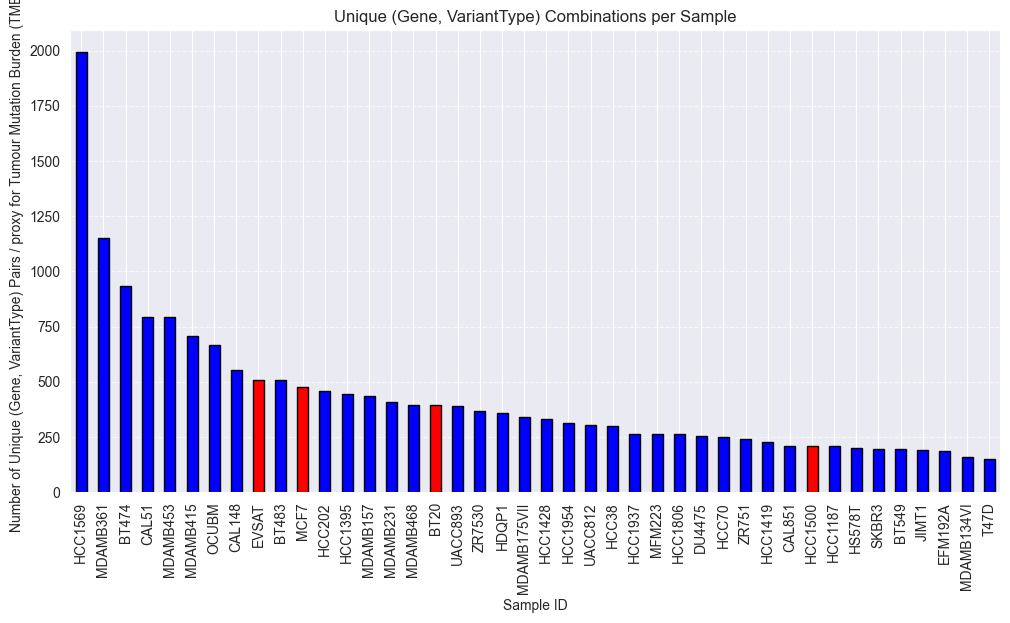

In [ ]:
# Assuming brca_mut_df is already loaded
# Compute the number of unique (gene, variantType) pairs per sampleId
unique_combinations = brca_mut_df.groupby("sampleId")[["gene", "variantType"]].apply(lambda x: x.drop_duplicates().shape[0])

# Plot the results
plt.figure(figsize=(12, 6))
unique_combinations.sort_values(ascending=False, inplace=True)
# Define special colors for specific cell lines
highlight_samples = {"BT20": "red", "MCF7": "red", "HCC1500": "red", "EVSAT": "red"}
colors = [highlight_samples.get(sample, "blue") for sample in unique_combinations.index]
unique_combinations.plot(kind='bar', color=colors, edgecolor='black')

plt.xlabel("Sample ID")
plt.ylabel("Number of Unique (Gene, VariantType) Pairs / proxy for Tumour Mutation Burden (TMB)")
plt.title("Unique (Gene, VariantType) Combinations per Sample")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


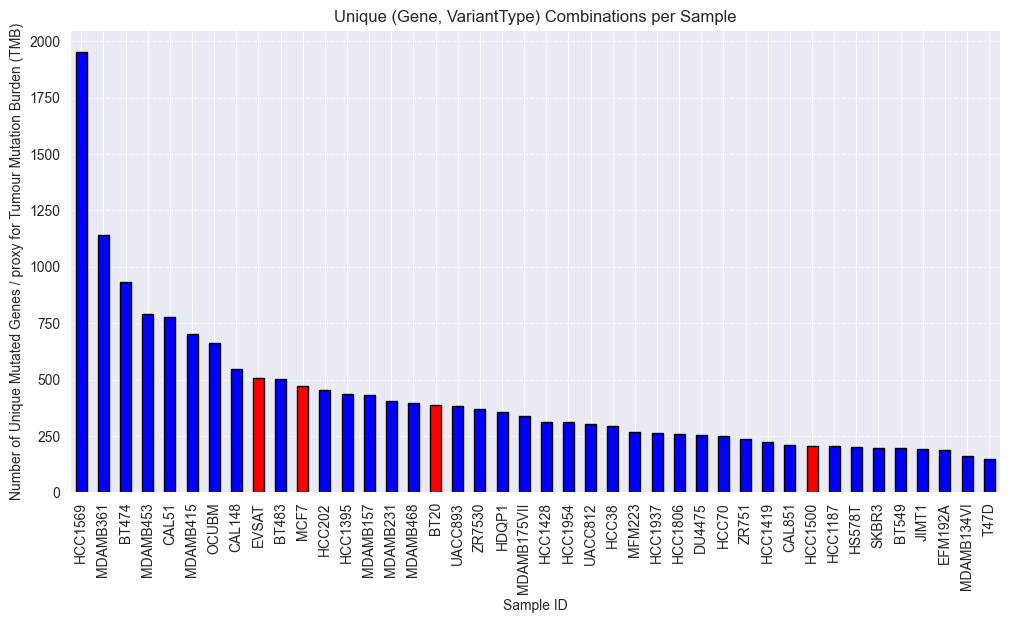

In [ ]:
# Assuming brca_mut_df is already loaded
# Compute the number of unique mutated genes per sampleId
unique_combinations = brca_mut_df.groupby("sampleId")[["gene"]].apply(lambda x: x.drop_duplicates().shape[0])

# Plot the results
plt.figure(figsize=(12, 6))
unique_combinations.sort_values(ascending=False, inplace=True)
# Define special colors for specific cell lines
highlight_samples = {"BT20": "red", "MCF7": "red", "HCC1500": "red", "EVSAT": "red"}
colors = [highlight_samples.get(sample, "blue") for sample in unique_combinations.index]
unique_combinations.plot(kind='bar', color=colors, edgecolor='black')

plt.xlabel("Sample ID")
plt.ylabel("Number of Unique Mutated Genes / proxy for Tumour Mutation Burden (TMB)")
plt.title("Unique (Gene, VariantType) Combinations per Sample")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


In [ ]:
from gprofiler import GProfiler

# Initialize g:Profiler
gp = GProfiler(return_dataframe=True)

# Query GO enrichment
go_results = gp.profile(organism="hsapiens", query=gene_list, sources=["GO:BP", "GO:MF", "GO:CC"])

go_results[go_results.source == "GO:BP"].sort_values(by="term_size", ascending=False)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
85,GO:BP,GO:0065007,biological regulation,1.561081e-09,True,"""Any process that modulates a measurable attri...",12743,878,631,21026,0.718679,0.049517,query_1,[GO:0008150]
90,GO:BP,GO:0050789,regulation of biological process,4.620585e-09,True,"""Any process that modulates the frequency, rat...",12336,878,613,21026,0.698178,0.049692,query_1,"[GO:0008150, GO:0065007]"
94,GO:BP,GO:0050794,regulation of cellular process,1.021117e-08,True,"""Any process that modulates the frequency, rat...",11946,878,596,21026,0.678815,0.049891,query_1,"[GO:0009987, GO:0050789]"
8,GO:BP,GO:0071840,cellular component organization or biogenesis,5.219593e-26,True,"""A process that results in the biosynthesis of...",8393,878,512,21026,0.583144,0.061003,query_1,[GO:0009987]
7,GO:BP,GO:0016043,cellular component organization,5.030084e-26,True,"""A process that results in the assembly, arran...",8184,878,503,21026,0.572893,0.061461,query_1,[GO:0071840]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,GO:BP,GO:0007157,heterophilic cell-cell adhesion via plasma mem...,2.651233e-02,True,"""The attachment of an adhesion molecule in one...",54,878,11,21026,0.012528,0.203704,query_1,[GO:0098742]
420,GO:BP,GO:0031112,positive regulation of microtubule polymerizat...,4.604480e-02,True,"""Any process that activates or increases the f...",38,878,9,21026,0.010251,0.236842,query_1,"[GO:0031109, GO:0031110, GO:0051495]"
421,GO:BP,GO:1902656,calcium ion import into cytosol,4.604480e-02,True,"""The directed movement of calcium ion into a c...",38,878,9,21026,0.010251,0.236842,query_1,[GO:0006816]
424,GO:BP,GO:0000212,meiotic spindle organization,4.830118e-02,True,"""A process that is carried out at the cellular...",22,878,7,21026,0.007973,0.318182,query_1,"[GO:0007051, GO:1903046]"


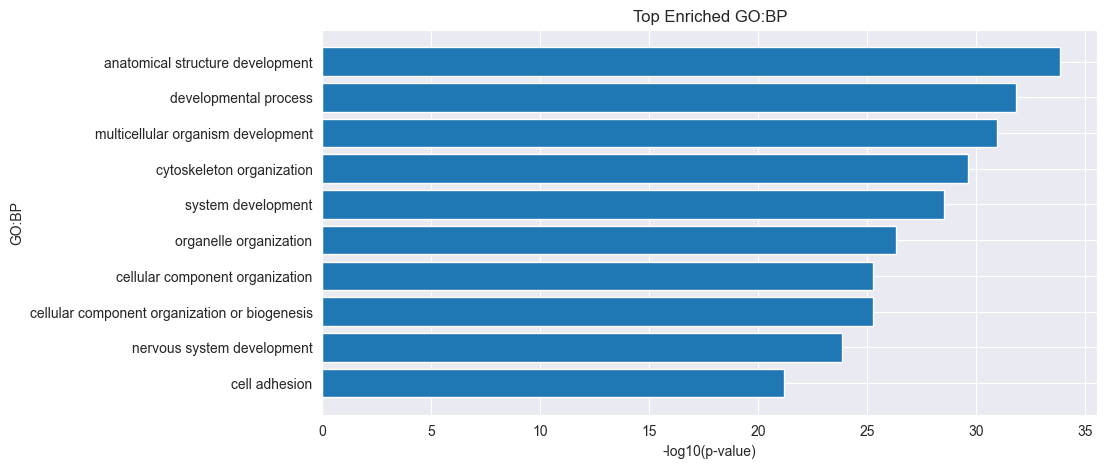

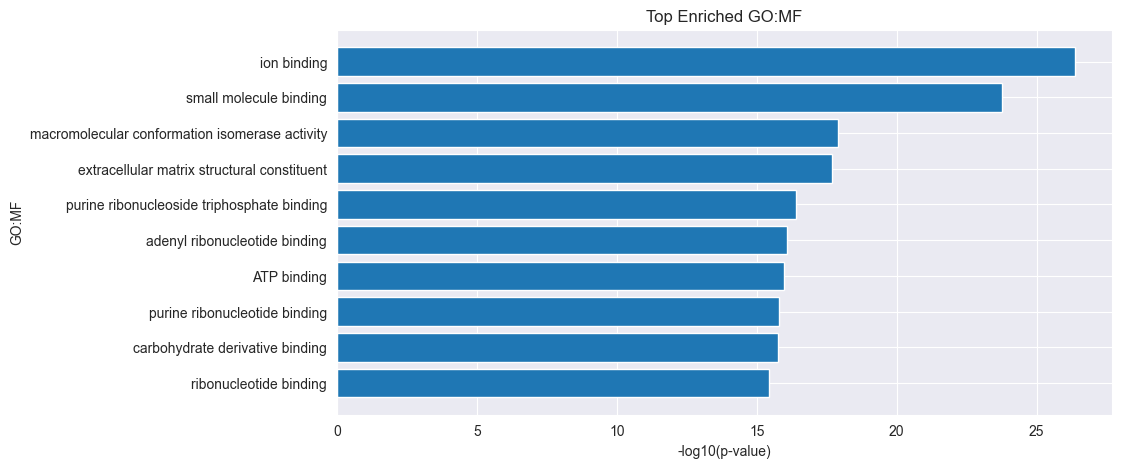

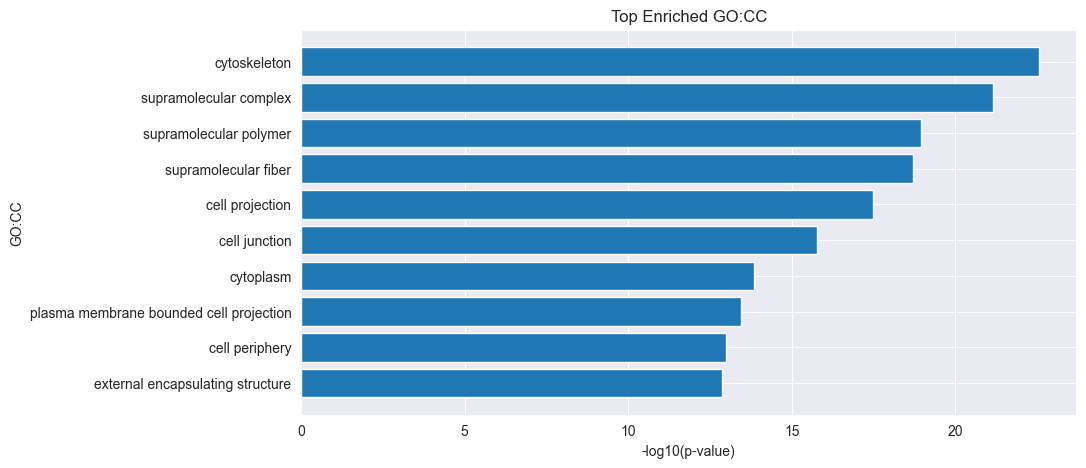

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

significant_go = go_results[go_results["p_value"] < 0.05]

for source in ["GO:BP", "GO:MF", "GO:CC"]:
    # Select top enriched GO terms (Biological Process)
    top_go = significant_go[significant_go["source"] == source].sort_values("p_value").head(10)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.barh(top_go["name"], -np.log10(top_go["p_value"]))
    plt.xlabel("-log10(p-value)")
    plt.ylabel(f"{source}")
    plt.title(f"Top Enriched {source}")
    plt.gca().invert_yaxis()
    plt.show()

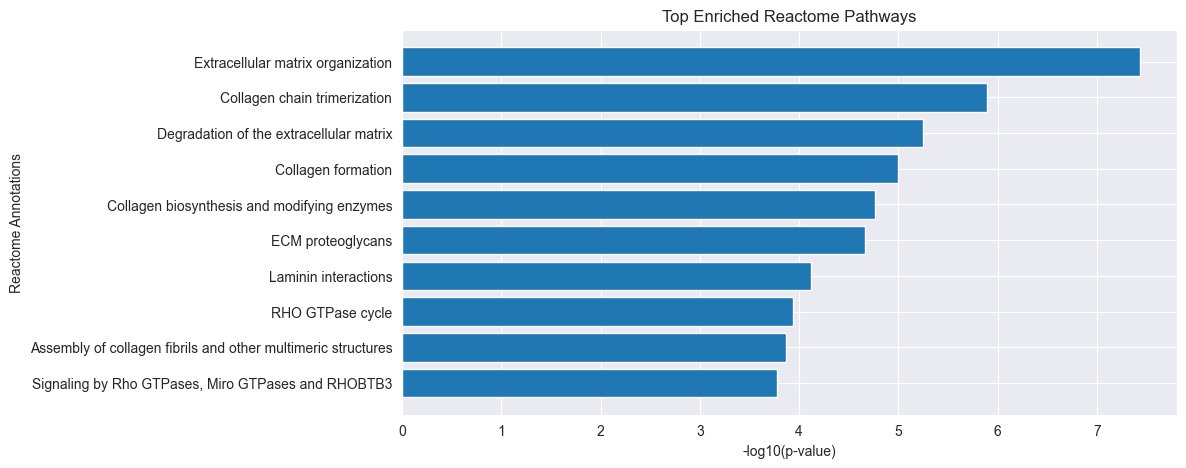

In [ ]:
# Query g:Profiler for pathway enrichment
gp = GProfiler(return_dataframe=True)
reactome_results = gp.profile(organism="hsapiens", query=gene_list, sources=["REAC"])

significant_reactome = reactome_results[reactome_results["p_value"] < 0.05]
# Select top enriched GO terms (Biological Process)
top_reac = significant_reactome.sort_values("p_value").head(10)

# Plot
plt.figure(figsize=(10, 5))
plt.barh(top_reac["name"], -np.log10(top_reac["p_value"]))
plt.xlabel("-log10(p-value)")
plt.ylabel("Reactome Annotations")
plt.title("Top Enriched Reactome Pathways")
plt.gca().invert_yaxis()
plt.show()

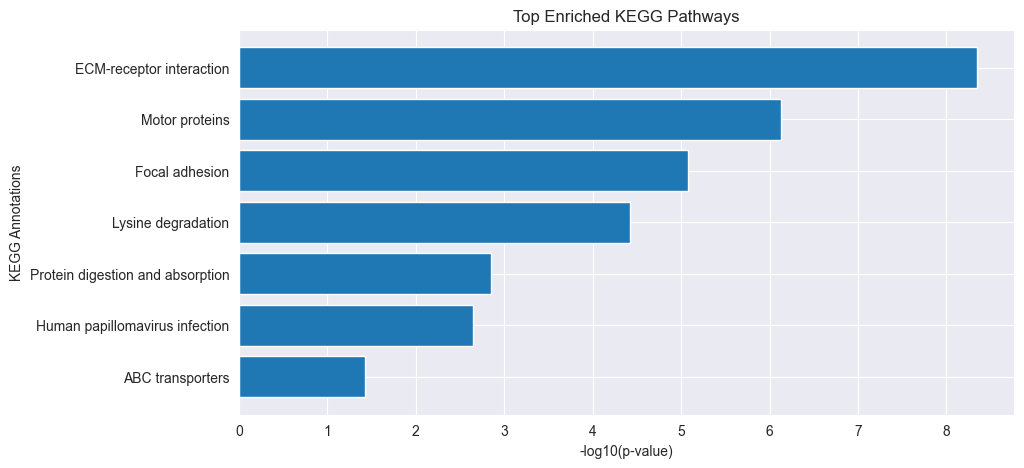

In [ ]:
# Query g:Profiler for pathway enrichment
gp = GProfiler(return_dataframe=True)
kegg_results = gp.profile(organism="hsapiens", query=gene_list, sources=["KEGG"])

significant_kegg = kegg_results[kegg_results["p_value"] < 0.05]
# Select top enriched GO terms (Biological Process)
top_kegg = significant_kegg.sort_values("p_value").head(20)

# Plot
plt.figure(figsize=(10, 5))
plt.barh(top_kegg["name"], -np.log10(top_kegg["p_value"]))
plt.xlabel("-log10(p-value)")
plt.ylabel("KEGG Annotations")
plt.title("Top Enriched KEGG Pathways")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from common import hardest_cell_lines
hardest_cell_lines_ids = [cl[1:] for cl in hardest_cell_lines]
brca_mut_val = brca_mut_df[brca_mut_df.sampleId.isin(hardest_cell_lines_ids)]
brca_mut_val

,Unnamed: 0,chr,entrezGeneId,gene,keyword,mutationType,sampleId,proteinChange,variantType
4413,4413,3,5290,PIK3CA,PIK3CA H1047 missense,Missense_Mutation,BT20,H1047R,SNP
4414,4414,3,5290,PIK3CA,PIK3CA P539 missense,Missense_Mutation,BT20,P539R,SNP
4415,4415,19,5424,POLD1,POLD1 truncating,Nonsense_Mutation,BT20,Q636*,SNP
4416,4416,2,9839,ZEB2,ZEB2 E1094 missense,Missense_Mutation,BT20,E1094K,SNP
4417,4417,20,140689,CBLN4,CBLN4 E85 missense,Missense_Mutation,BT20,E85K,SNP
...,...,...,...,...,...,...,...,...,...
18065,18065,19,199704,ZNF585A,ZNF585A truncating,Frame_Shift_Ins,HCC1500,D674Afs*6,INS
18066,18066,19,199704,ZNF585A,ZNF585A truncating,Frame_Shift_Del,HCC1500,T673Rfs*7,DEL
18067,18067,1,100132406,NBPF10,NaN,In_Frame_Ins,HCC1500,R2726dup,INS
18068,18068,2,653269,POTEI,POTEI truncating,Frame_Shift_Del,HCC1500,S337Dfs*15,DEL


In [ ]:
brca_mut_val.groupby(["keyword", "variantType"])[["sampleId"]].count().sort_values(by="sampleId", ascending=False)

,,sampleId
keyword,variantType,
MALRD1 A114 missense,SNP,2
MAGEA2B M247 missense,SNP,2
PKD2L1 G291 missense,SNP,2
PTPRD truncating,SNP,2
MMP17 G36 missense,SNP,2
...,...,...
FMO3 T121 missense,SNP,1
FLT3 C368 missense,DNP,1
FLNC G54 missense,SNP,1


In [ ]:
mutcount_df = brca_mut_df.dropna(subset=["keyword"]).groupby(["keyword", "variantType"])["sampleId"].count().reset_index().rename(columns={"sampleId": "mutCount"}).sort_values(by="mutCount", ascending=False)

In [ ]:
mutcount_df

,keyword,variantType,mutCount
3101,CLDN8 truncating,INS,8
11584,PIK3CA H1047 missense,SNP,8
7987,KRT85 L403 missense,SNP,7
7948,KRT16 truncating,DEL,6
6360,GRAMD2A truncating,INS,6
...,...,...,...
6127,GLI1 L478 missense,SNP,1
6128,GLI2 K485 missense,SNP,1
6129,GLI2 M1222 missense,SNP,1
6130,GLI3 R905 missense,SNP,1


In [ ]:
mutcount_df[mutcount_df.mutCount >= 4]

,keyword,variantType,mutCount
3101,CLDN8 truncating,INS,8
11584,PIK3CA H1047 missense,SNP,8
7987,KRT85 L403 missense,SNP,7
7948,KRT16 truncating,DEL,6
6360,GRAMD2A truncating,INS,6
16373,TTC3 truncating,INS,5
15992,TP53 truncating,SNP,5
8537,LTN1 truncating,INS,5
12445,PTEN truncating,DEL,5
13785,SF3B1 truncating,INS,4


In [ ]:
brca_mut_df[(brca_mut_df["keyword"] == "TP53 truncating") & (brca_mut_df.sampleId == "HCC1569_BREAST")]

,Unnamed: 0,chr,entrezGeneId,gene,keyword,mutationType,sampleId,proteinChange,variantType


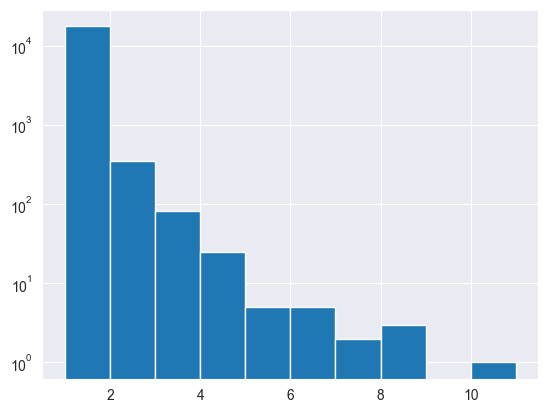

In [ ]:
plt.hist(brca_mut_df.groupby("keyword")["sampleId"].count().reset_index()["sampleId"].values)
plt.yscale("log")
plt.show()

In [ ]:
brca_mut_df.groupby("keyword")["sampleId"].count().reset_index()["sampleId"].values

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
brca_filtered = brca_mut_df.dropna(subset=["keyword"])
brca_filtered = brca_filtered[brca_filtered["keyword"].str.contains("EGFR")]
brca_filtered

,Unnamed: 0,chr,entrezGeneId,gene,keyword,mutationType,sampleId,proteinChange,variantType
668,668,7,1956,EGFR,EGFR R309 missense,Missense_Mutation,HCC38,R309G,SNP
5065,5065,7,1956,EGFR,EGFR T678 missense,Missense_Mutation,MDAMB361,T678M,SNP
12163,12163,7,1956,EGFR,EGFR E711 missense,Missense_Mutation,EVSAT,E711K,SNP
